# data preprocessing

In [47]:
! pip install numpy

In [48]:
!pip install matplotlib
!pip install pandas

data cleaning

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
customer_purchase = pd.read_csv("customer_purchase.csv")

In [51]:
print("Dataset Head:")
print(customer_purchase.head())

Dataset Head:
   Customer_Age  Gender Location  Monthly_Income  Visits_Per_Month  Avg_Spend  \
0            56    Male    Urban           60612                 9       2434   
1            46  Female    Urban           33574                 9       2241   
2            32    Male    Rural           33524                10       2028   
3            25    Male    Rural           79172                 9       2308   
4            38  Female    Urban           20916                 3       4268   

  Purchase_Frequency  
0             Medium  
1             Medium  
2             Medium  
3             Medium  
4                Low  


In [52]:
print("\nDataset Info:")
print(customer_purchase.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_Age        300 non-null    int64 
 1   Gender              300 non-null    object
 2   Location            300 non-null    object
 3   Monthly_Income      300 non-null    int64 
 4   Visits_Per_Month    300 non-null    int64 
 5   Avg_Spend           300 non-null    int64 
 6   Purchase_Frequency  300 non-null    object
dtypes: int64(4), object(3)
memory usage: 16.5+ KB
None


In [53]:
print("\nMissing Values:")
print(customer_purchase.isnull().sum())


Missing Values:
Customer_Age          0
Gender                0
Location              0
Monthly_Income        0
Visits_Per_Month      0
Avg_Spend             0
Purchase_Frequency    0
dtype: int64


In [54]:
int(customer_purchase.duplicated().sum())
print("Duplicate rows:", int(customer_purchase.duplicated().sum()))

Duplicate rows: 0



Target Distribution:
Purchase_Frequency
High      116
Medium    107
Low        77
Name: count, dtype: int64


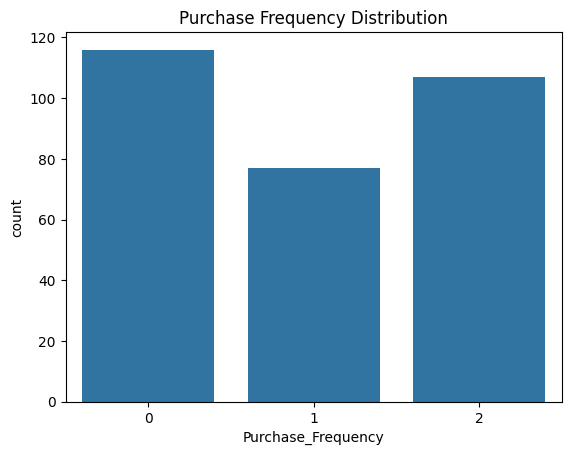

In [55]:
print("\nTarget Distribution:")
print(customer_purchase['Purchase_Frequency'].value_counts())

sns.countplot(x='Purchase_Frequency', data=df)
plt.title("Purchase Frequency Distribution")
plt.show()

# ml processing

 Import Libraries

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


 Encode Categorical Columns: Gender & Location

In [57]:
le_gender = LabelEncoder()
le_location = LabelEncoder()
le_target = LabelEncoder()

customer_purchase['Gender'] = le_gender.fit_transform(customer_purchase['Gender'])
customer_purchase['Location'] = le_location.fit_transform(customer_purchase['Location'])
customer_purchase['Purchase_Frequency'] = le_target.fit_transform(customer_purchase['Purchase_Frequency'])

Feature Columns & Target

In [58]:
X = customer_purchase.drop('Purchase_Frequency', axis=1)
y = customer_purchase['Purchase_Frequency']

scaler = StandardScaler()
X[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']] = scaler.fit_transform(
    X[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']]
)


Train-Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


 Random Forest Classifier

In [60]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Logistic Regression

In [61]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

 Random Forest


Random Forest Accuracy: 1.0
Random Forest Confusion Matrix:


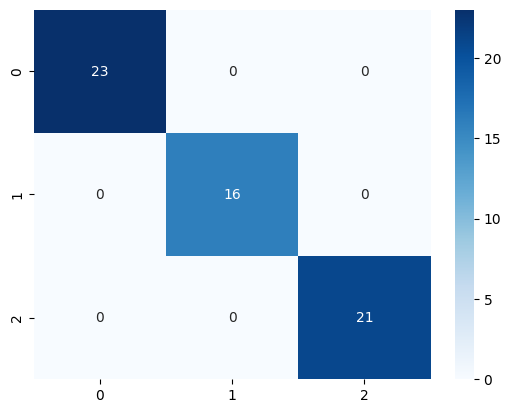


Random Forest Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00        23
         Low       1.00      1.00      1.00        16
      Medium       1.00      1.00      1.00        21

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [62]:
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.show()
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf, target_names=le_target.classes_))


Logistic Regression Accuracy: 0.95
Logistic Regression Confusion Matrix:


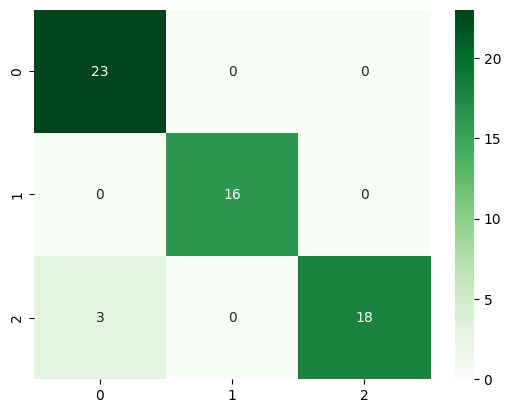


Logistic Regression Classification Report:
               precision    recall  f1-score   support

        High       0.88      1.00      0.94        23
         Low       1.00      1.00      1.00        16
      Medium       1.00      0.86      0.92        21

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.96      0.95      0.95        60



In [64]:
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Greens")
plt.show()
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr, target_names=le_target.classes_))


feature importance


Feature Importances (Random Forest):
            Feature  Importance
4  Visits_Per_Month    0.798376
3    Monthly_Income    0.064790
5         Avg_Spend    0.062139
0      Customer_Age    0.058648
2          Location    0.008111
1            Gender    0.007936


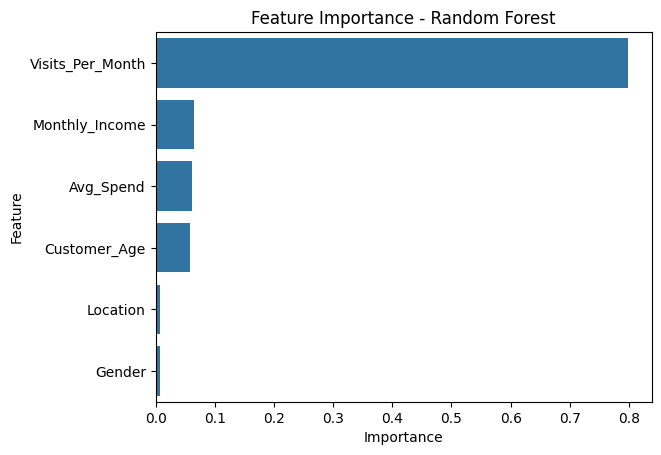

In [65]:
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances (Random Forest):")
print(feat_imp_df)

sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Feature Importance - Random Forest")
plt.show()

accuracy

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9833333333333333


**example** prediction

example 1

In [68]:
new_data = pd.DataFrame({
     'Customer_Age':[30],
     'Gender':[le_gender.transform(['Male'])[0]],
     'Location':[le_location.transform(['Urban'])[0]],
     'Monthly_Income':[50000],
     'Visits_Per_Month':[5],
     'Avg_Spend':[1500]
 })
new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']] = scaler.transform(
    new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']]
)
pred = le_target.inverse_transform(rf_model.predict(new_data))
print("Predicted Purchase Frequency:", pred[0])

Predicted Purchase Frequency: Low


example 2

In [71]:
new_data = pd.DataFrame({
     'Customer_Age':[20],
     'Gender':[le_gender.transform(['Female'])[0]],
     'Location':[le_location.transform(['Rural'])[0]],
     'Monthly_Income':[45000],
     'Visits_Per_Month':[8],
     'Avg_Spend':[2500]
 })
new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']] = scaler.transform(
    new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']]
)
pred = le_target.inverse_transform(rf_model.predict(new_data))
print("Predicted Purchase Frequency:", pred[0])

Predicted Purchase Frequency: Medium


example 3

In [79]:
new_data = pd.DataFrame({
     'Customer_Age':[40],
     'Gender':[le_gender.transform(['Male'])[0]],
     'Location':[le_location.transform(['Urban'])[0]],
     'Monthly_Income':[100000],
     'Visits_Per_Month':[10],
     'Avg_Spend':[5500]
 })
new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']] = scaler.transform(
    new_data[['Customer_Age','Monthly_Income','Visits_Per_Month','Avg_Spend']]
)
pred = le_target.inverse_transform(rf_model.predict(new_data))
print("Predicted Purchase Frequency:", pred[0])

Predicted Purchase Frequency: Medium
